## Collecte et préparation des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style("whitegrid")

In [3]:
fake_url = "https://raw.githubusercontent.com/davidamouzou/Fake_news/main/data/fake.csv"
true_url = "https://raw.githubusercontent.com/davidamouzou/Fake_news/main/data/real.csv"

# Load the datasets
fake_df = pd.read_csv(fake_url)
true_df = pd.read_csv(true_url)

# Add a label column to both dataframes
fake_df["label"] = 0
true_df["label"] = 1

# Combine the two dataframes into one
df = pd.concat([fake_df, true_df], ignore_index=True)
df

,id,title,text,subject,date,label
0,1,"""Breaking: New Study Finds Coffee Extends Lif...","""Researchers claim drinking 5 cups daily adds...",politics,2024-01-15,0
1,2,"""Celebrities Unite for Secret Project""","""Multiple A-list actors spotted meeting in un...",entertainment,2024-01-16,0
2,3,"""Economic Boom Expected This Quarter""","""Analysts predict 8% growth despite market co...",business,2024-01-17,0
3,4,"""Tech Giant Announces Revolutionary Invention""","""Company claims to have solved climate change...",science,2024-01-18,0
4,5,"""Local Hero Saves 100 People in One Day""","""Unknown citizen rescues families from disaster""",world,2024-01-19,0
...,...,...,...,...,...,...
206,102,Jazz Festival Attracts International Musicians,Festival celebrates diverse musical styles and...,entertainment,2025-11-08,1
207,103,Ocean Temperature Monitoring Reveals Warming T...,Scientists document rate of change in marine e...,climate,2025-11-07,1
208,104,New Antibiotic Effective Against Resistant Bac...,Pharmaceutical breakthrough addresses critical...,health,2025-11-06,1
209,105,Venture Capital Funding Reaches Record Levels,Investors allocate billions to promising start...,business,2025-11-05,1


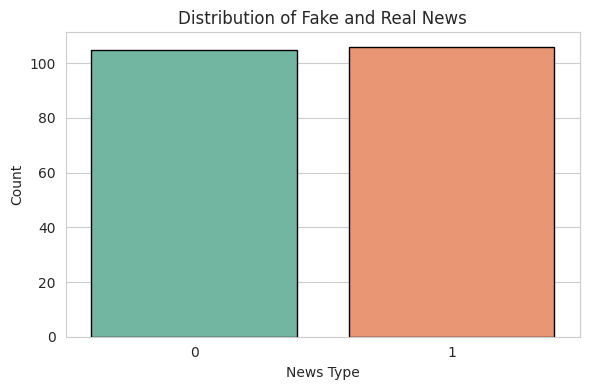

In [4]:
# Plotting the distribution of labels
plt.figure(figsize=(6, 4))
sns.countplot(x="label", hue="label", data=df, palette="Set2", legend=False, edgecolor='black')
plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

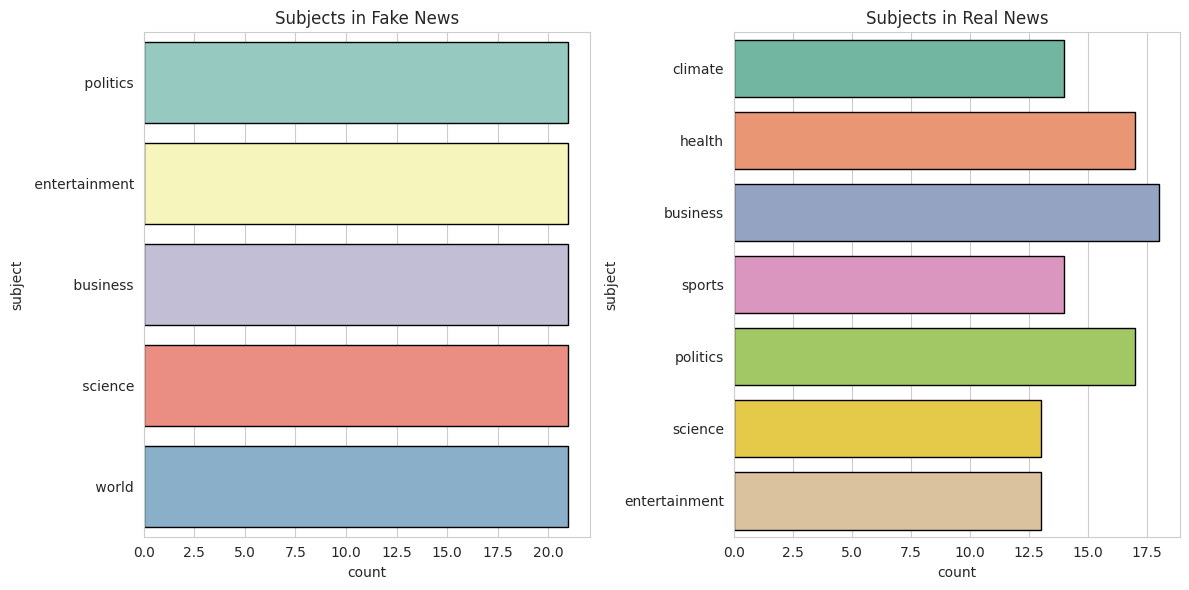

In [5]:
# Distribution of subjects in fake and real news
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(y="subject", hue="subject", data=fake_df, palette="Set3", edgecolor='black')
plt.title("Subjects in Fake News")
plt.subplot(1, 2, 2)
sns.countplot(y="subject", hue="subject", data=true_df, palette="Set2", edgecolor='black')
plt.title("Subjects in Real News")
plt.tight_layout()
plt.show()

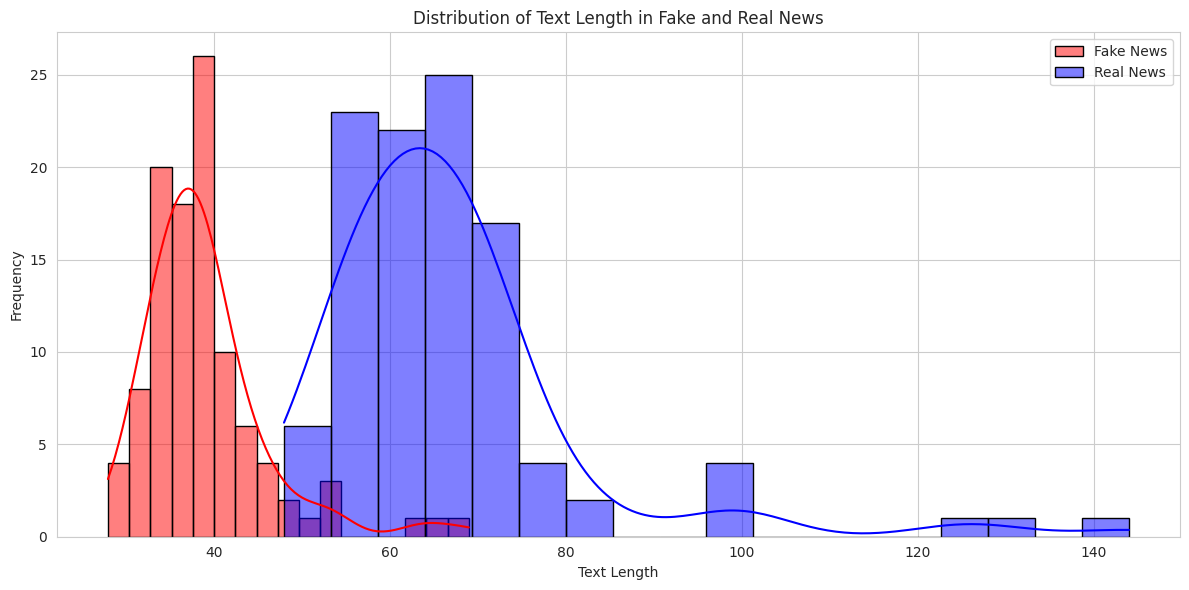

In [6]:
# Length of text in fake and real news
fake_df["text_length"] = fake_df["text"].apply(len)
true_df["text_length"] = true_df["text"].apply(len)
plt.figure(figsize=(12, 6))
sns.histplot(fake_df["text_length"], color="red", label="Fake News", kde=True, edgecolor='black')
sns.histplot(true_df["text_length"], color="blue", label="Real News", kde=True, edgecolor='black')
plt.title("Distribution of Text Length in Fake and Real News")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
from collections import Counter
from wordcloud import STOPWORDS
import nltk

# Download necessary NLTK resources if not already downloaded
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
# Definde a function to preprocess text
def preprocess_text(text):
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    # Remove stop words and punctuation
    stop_words = set(nltk.corpus.stopwords.words('english'))
    tokens = [word for word in tokens if word.isalpha() and word.lower() not in stop_words]
    return tokens

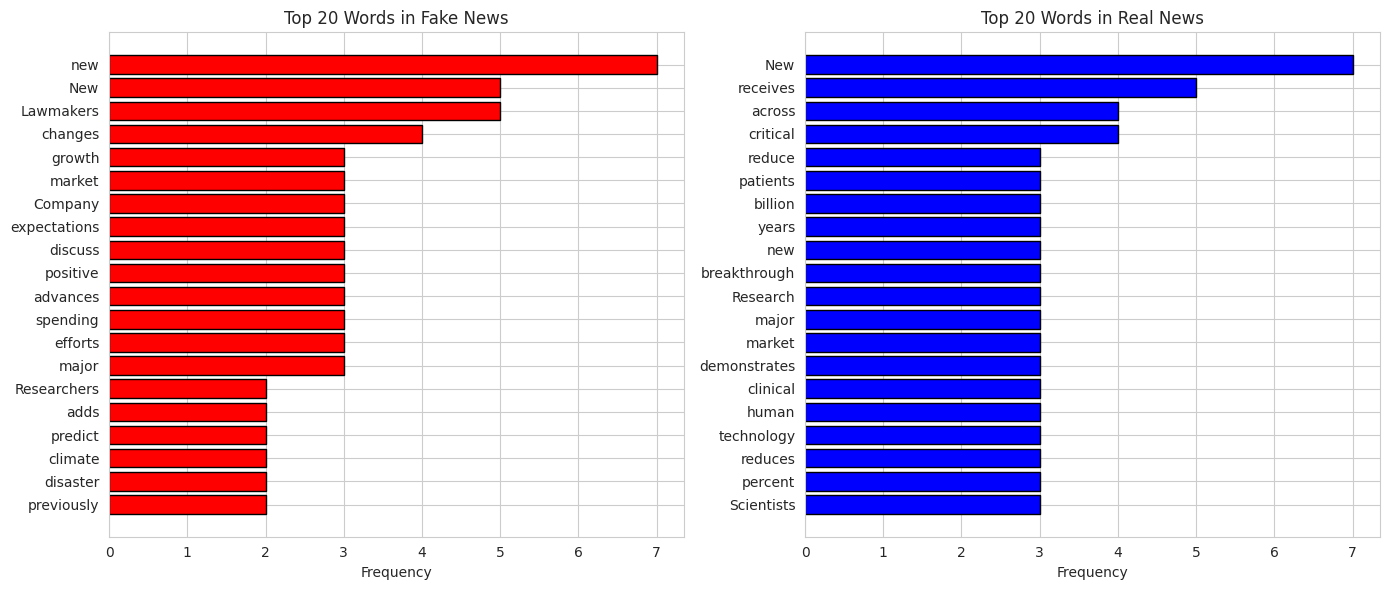

In [9]:
# Tokenize the text in the combined dataframe
df["tokens"] = df["text"].apply(preprocess_text)

# Separate tokens by label
fake_tokens = df[df["label"] == 0]["tokens"]
real_tokens = df[df["label"] == 1]["tokens"]

# Get the most common words
fake_words = Counter([word for tokens in fake_tokens for word in tokens])
real_words = Counter([word for tokens in real_tokens for word in tokens])

# Visualize the most common words
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fake_top_words = fake_words.most_common(20)
real_top_words = real_words.most_common(20)

# Plot fake news top words
fake_words_df = pd.DataFrame(fake_top_words, columns=['word', 'count'])
axes[0].barh(fake_words_df['word'], fake_words_df['count'], color='red', edgecolor='black')
axes[0].set_title('Top 20 Words in Fake News')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Plot real news top words
real_words_df = pd.DataFrame(real_top_words, columns=['word', 'count'])
axes[1].barh(real_words_df['word'], real_words_df['count'], color='blue', edgecolor='black')
axes[1].set_title('Top 20 Words in Real News')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Préprocessing du texte

#### Caractéristiques textuelles simples

In [10]:
# Flesch Reading Ease and Flesch-Kincaid Grade Level
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.9 MB/s eta 0:00:0000:01


In [11]:
from textstat import flesch_reading_ease, flesch_kincaid_grade
import re

In [12]:
# Extract readability metrics directly on the combined dataframe
df["flesch_reading_ease"] = df["text"].apply(flesch_reading_ease)
df["flesch_kincaid_grade"] = df["text"].apply(flesch_kincaid_grade)

# Optional: compare fake (0) vs real (1)
df.groupby("label")[["flesch_reading_ease", "flesch_kincaid_grade"]].mean()

,flesch_reading_ease,flesch_kincaid_grade
label,,
0,-4.446946,14.991596
1,-2.334375,15.599300


In [13]:
def extract_text_features(df):
    """Extrait des caractéristiques du texte"""
    
    # Longueur du texte
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    
    # Caractéristiques de lisibilité
    df['flesch_score'] = df['text'].apply(lambda x: flesch_reading_ease(x) if pd.notna(x) else 0)
    df['flesch_kincaid'] = df['text'].apply(lambda x: flesch_kincaid_grade(x) if pd.notna(x) else 0)
    
    # Mots en majuscules (souvent dans fake news)
    df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
    
    # Points d'exclamation et d'interrogation
    df['exclamation_count'] = df['text'].str.count(r'\!')
    df['question_count'] = df['text'].str.count(r'\?')
    
    return df

df = extract_text_features(df)

In [14]:
# sauvegarder le dataset
df.to_csv('df_processed.csv', index=False)